# Spectre d'un fichier MP3

Ce notebook charge un MP3 puis affiche :
- son spectrogramme (spectre en fonction du temps)
- son spectre moyen en frequence

Par defaut, il utilise `premier-enregistrement.mp3` dans le meme dossier.

In [2]:
# Si besoin, decommenter la ligne suivante :
# %pip install numpy matplotlib librosa

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

try:
    import librosa
    import librosa.display
except ImportError as exc:
    raise ImportError(
        "librosa n'est pas installe. Lance: %pip install librosa"
    ) from exc

In [3]:
# Chemin du MP3 (modifie si besoin)
mp3_path = Path("premier-enregistrement.mp3")

if not mp3_path.exists():
    raise FileNotFoundError(f"Fichier introuvable: {mp3_path.resolve()}")

# Chargement en mono pour une analyse simple
signal, sr = librosa.load(mp3_path, sr=None, mono=True)
duration = len(signal) / sr

print(f"Fichier : {mp3_path}")
print(f"Frequence d'echantillonnage : {sr} Hz")
print(f"Duree : {duration:.2f} s")

e:\anaconda\envs\sophia\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fichier : premier-enregistrement.mp3
Frequence d'echantillonnage : 44100 Hz
Duree : 23.80 s


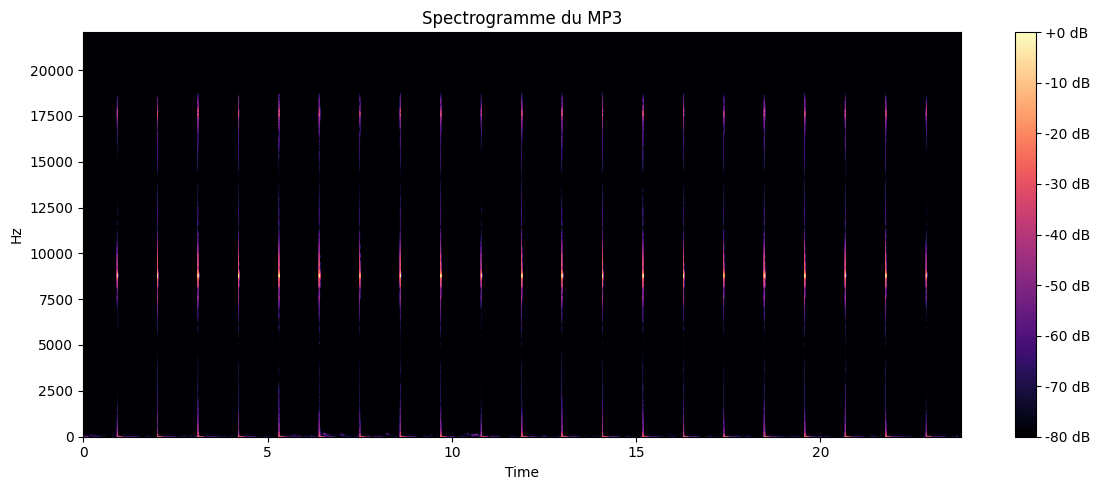

In [4]:
# Spectrogramme (STFT -> echelle en dB)
S = np.abs(librosa.stft(signal, n_fft=2048, hop_length=512))
S_db = librosa.amplitude_to_db(S, ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis="time", y_axis="hz", cmap="magma")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogramme du MP3")
plt.tight_layout()
plt.show()

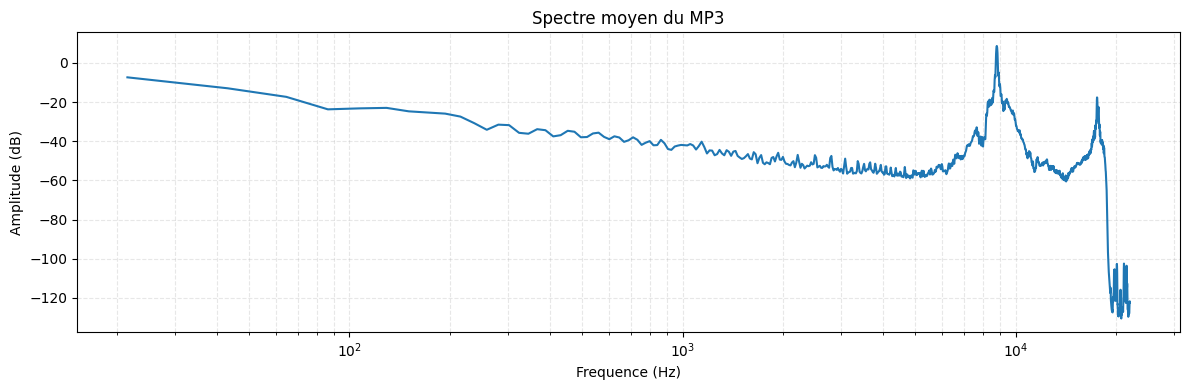

In [5]:
# Spectre moyen en frequence (moyenne temporelle du module de la STFT)
freqs = librosa.fft_frequencies(sr=sr, n_fft=2048)
mean_spectrum = S.mean(axis=1)

plt.figure(figsize=(12, 4))
plt.semilogx(freqs[1:], 20 * np.log10(mean_spectrum[1:] + 1e-10))
plt.xlabel("Frequence (Hz)")
plt.ylabel("Amplitude (dB)")
plt.title("Spectre moyen du MP3")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()